# Предсказание аритмии:
1. Базовый DL-блок (простые MLP),
2. Улучшенные архитектуры (v2),
3. Ансамбли DL + CatBoost (v3),
4. Финальные усиления v3.1 (5 seeds, калибровка, blend 0.01, OOF stacking).

In [1]:
!pip install tensorflow catboost -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


## 0) Импорты и глобальные настройки

In [2]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, fbeta_score, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from catboost import CatBoostClassifier

SEED = 42
TARGET_COL = 'target_arrhythmia'
BETA = 3
RECALL_MIN = 0.93

os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

## 1) Данные и подготовка признаков

In [3]:
df = pd.read_csv('2025_11_26_eda_final_ecg_data.csv', low_memory=False)

categorical_columns = ['heart_axis_norm', 'V1_pathological_Q']
numeric_columns = [
    'age', 'I_prop_censored', 'II_wavelet_entropy', 'II_SNR_dB', 'III_PSD_std_freq',
    'III_wavelet_E2', 'AVR_RMSSD', 'AVR_STFT_energy', 'AVR_SNR_dB', 'AVR_prop_censored',
    'AVL_STFT_energy', 'AVL_SNR_dB', 'AVF_SNR_dB', 'V1_RMSSD', 'V1_STFT_energy',
    'V1_wavelet_entropy', 'V1_SNR_dB', 'V2_STFT_energy', 'V2_SNR_dB', 'V2_Q_wave_amp',
    'V3_STFT_energy', 'V3_SNR_dB', 'V3_Q_wave_amp', 'V4_STFT_energy', 'V4_SNR_dB',
    'V5_SNR_dB', 'V5_prop_censored', 'V5_Q_wave_amp', 'V6_STFT_energy', 'V6_SNR_dB',
    'V6_prop_censored', 'meanRR_global', 'V3_PSD_mean_freq', 'V5_PSD_std_freq',
    'AVF_wavelet_E5', 'I_wavelet_E5', 'I_wavelet_entropy',
]

df['target_patology'] = 1 - df['target_norm']
target_columns = ['target_patology', 'target_norm', 'target_arrhythmia', 'target_infarction']

X = df.drop(columns=target_columns)
y = df[TARGET_COL].astype(int)

X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.2, random_state=SEED, stratify=y_trainval)

scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[numeric_columns])
X_val_num = scaler.transform(X_val[numeric_columns])
X_test_num = scaler.transform(X_test[numeric_columns])

X_train_final = np.hstack([X_train_num, X_train[categorical_columns].values]).astype('float32')
X_val_final = np.hstack([X_val_num, X_val[categorical_columns].values]).astype('float32')
X_test_final = np.hstack([X_test_num, X_test[categorical_columns].values]).astype('float32')

print('Shapes:', X_train_final.shape, X_val_final.shape, X_test_final.shape)
print('Positive rate:', round(float(y.mean()), 4))

Shapes: (6267, 39) (1567, 39) (1959, 39)
Positive rate: 0.2416


## 2) Универсальные функции (метрики, пороги, обучение)

In [7]:
def reset_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

def class_weight_with_multiplier(y_series, pos_multiplier=1.0):
    classes = np.array([0, 1])
    w = compute_class_weight(class_weight='balanced', classes=classes, y=y_series)
    d = {int(c): float(v) for c, v in zip(classes, w)}
    d[1] *= pos_multiplier
    return d

def threshold_table(y_true, proba, beta=BETA, step=0.05):
    rows = []
    for t in np.arange(0.05, 1.0, step):
        pred = (proba >= t).astype(int)
        rows.append({
            'threshold': round(float(t), 2),
            'precision': precision_score(y_true, pred, zero_division=0),
            'recall': recall_score(y_true, pred, zero_division=0),
            'fbeta': fbeta_score(y_true, pred, beta=beta, zero_division=0),
        })
    return pd.DataFrame(rows)

def pick_threshold(y_true, proba, beta=BETA, recall_min=None, step=0.05):
    tdf = threshold_table(y_true, proba, beta=beta, step=step)
    if recall_min is not None:
        cand = tdf[tdf['recall'] >= recall_min]
        if len(cand) > 0:
            return float(cand.loc[cand['fbeta'].idxmax(), 'threshold']), tdf
    return float(tdf.loc[tdf['fbeta'].idxmax(), 'threshold']), tdf

def metrics_at(y_true, proba, thr, beta=BETA):
    pred = (proba >= thr).astype(int)
    return {
        'precision': precision_score(y_true, pred, zero_division=0),
        'recall': recall_score(y_true, pred, zero_division=0),
        'f2': fbeta_score(y_true, pred, beta=beta, zero_division=0),
    }

def compile_dl(model, lr=1e-3, loss_name='bce'):
    loss_fn = keras.losses.BinaryFocalCrossentropy(gamma=2.0) if loss_name == 'focal' else 'binary_crossentropy'
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[keras.metrics.AUC(name='auc'), keras.metrics.AUC(name='pr_auc', curve='PR')],
    )
    return model

def fit_one_dl(model, cfg, xtr, ytr, xva, yva):
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_pr_auc', mode='max', patience=14, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_pr_auc', mode='max', factor=0.5, patience=5, min_lr=1e-5),
    ]
    cw = class_weight_with_multiplier(ytr, pos_multiplier=cfg.get('pos_multiplier', 1.0))
    model.fit(
        xtr, ytr,
        validation_data=(xva, yva),
        epochs=cfg.get('epochs', 180),
        batch_size=cfg.get('batch_size', 128),
        class_weight=cw,
        callbacks=callbacks,
        verbose=0,
    )
    return model

def predict_mc_dropout(model, x, n_passes=20):
    preds = []
    for _ in range(n_passes):
        preds.append(model(x, training=True).numpy().ravel())
    return np.mean(np.vstack(preds), axis=0)

def run_candidates(family_name, build_fn, candidates, threshold_step=0.05, recall_min=None):
    rows = []
    best = None
    for i, cfg in enumerate(candidates, 1):
        reset_seed(SEED + i)
        model = build_fn(cfg, X_train_final.shape[1])
        model = compile_dl(model, lr=cfg.get('lr', 1e-3), loss_name=cfg.get('loss', 'bce'))
        model = fit_one_dl(model, cfg, X_train_final, y_train, X_val_final, y_val)
        val_p = model.predict(X_val_final, verbose=0).ravel()
        test_p = model.predict(X_test_final, verbose=0).ravel()
        thr, _ = pick_threshold(y_val.values, val_p, beta=BETA, recall_min=recall_min, step=threshold_step)
        vm = metrics_at(y_val, val_p, thr, beta=BETA)
        tm = metrics_at(y_test, test_p, thr, beta=BETA)
        row = {
            'family': family_name,
            'candidate': i,
            'loss': cfg.get('loss', 'bce'),
            'val_f2': vm['f2'], 'test_f2': tm['f2'],
            'val_recall': vm['recall'], 'test_recall': tm['recall'],
            'threshold': thr,
            **{k: v for k, v in cfg.items() if k in ['lr', 'pos_multiplier']}
        }
        rows.append(row)
        if best is None or row['val_f2'] > best['best_val_f2']:
            best = {
                'best_val_f2': row['val_f2'],
                'row': row,
                'cfg': cfg,
                'val_proba': val_p,
                'test_proba': test_p
            }
    return pd.DataFrame(rows).sort_values('val_f2', ascending=False).reset_index(drop=True), best

## 3) A: Базовые DL-модели

In [5]:
def build_mlp_small(cfg, input_dim):
    return keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.25),
        layers.Dense(32, activation='relu'),
        layers.Dropout(0.20),
        layers.Dense(1, activation='sigmoid'),
    ])

def build_mlp_deep(cfg, input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(256)(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.35)(x)
    x = layers.Dense(128)(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out)

def build_residual(cfg, input_dim):
    inp = layers.Input(shape=(input_dim,))
    x = layers.Dense(128, activation='relu')(inp)
    skip = x
    h = layers.Dense(128, activation='relu')(x)
    h = layers.Dropout(0.2)(h)
    h = layers.Dense(128)(h)
    x = layers.Activation('relu')(layers.Add()([skip, h]))
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inp, out)

baseline_cfg = [{'lr': 1e-3, 'epochs': 140, 'batch_size': 128, 'pos_multiplier': 1.0, 'loss': 'bce'}]
t_small, b_small = run_candidates('MLP_small_baseline', build_mlp_small, baseline_cfg)
t_deep, b_deep = run_candidates('MLP_deep_baseline', build_mlp_deep, baseline_cfg)
t_res, b_res = run_candidates('Residual_baseline', build_residual, baseline_cfg)

stage_a = pd.concat([t_small.head(1), t_deep.head(1), t_res.head(1)], ignore_index=True)
display(stage_a[['family', 'val_f2', 'test_f2', 'val_recall', 'test_recall', 'threshold']].round(4))

,family,val_f2,test_f2,val_recall,test_recall,threshold
0,MLP_small_baseline,0.8012,0.8080,0.9103,0.9175,0.25
1,MLP_deep_baseline,0.8102,0.7871,0.8839,0.8584,0.25
2,Residual_baseline,0.8024,0.8040,0.9367,0.9408,0.20


## 4) B: Улучшенные модели DL

In [8]:
def build_widedeep(cfg, input_dim):
    inp = layers.Input(shape=(input_dim,))
    wide = layers.Dense(1)(inp)
    x = layers.Dense(cfg.get('u1', 256), activation='relu', kernel_regularizer=regularizers.l2(cfg.get('l2', 1e-5)))(inp)
    x = layers.Dropout(cfg.get('d1', 0.25))(x)
    x = layers.Dense(cfg.get('u2', 128), activation='relu')(x)
    x = layers.Dropout(cfg.get('d2', 0.15))(x)
    deep = layers.Dense(1)(x)
    out = layers.Activation('sigmoid')(layers.Add()([wide, deep]))
    return keras.Model(inp, out)

def build_selu(cfg, input_dim):
    return keras.Sequential([
        layers.Input(shape=(input_dim,)),
        layers.Dense(cfg.get('u1', 256), activation='selu', kernel_initializer='lecun_normal'),
        layers.AlphaDropout(cfg.get('d1', 0.15)),
        layers.Dense(cfg.get('u2', 128), activation='selu', kernel_initializer='lecun_normal'),
        layers.AlphaDropout(cfg.get('d2', 0.10)),
        layers.Dense(1, activation='sigmoid'),
    ])

wd_candidates = [
    {'u1': 256, 'u2': 128, 'd1': 0.25, 'd2': 0.15, 'lr': 8e-4, 'pos_multiplier': 1.0, 'loss': 'bce'},
    {'u1': 320, 'u2': 160, 'd1': 0.30, 'd2': 0.20, 'lr': 7e-4, 'pos_multiplier': 1.1, 'loss': 'focal'},
    {'u1': 224, 'u2': 112, 'd1': 0.20, 'd2': 0.10, 'lr': 1e-3, 'pos_multiplier': 0.95, 'loss': 'bce'},
]

selu_candidates = [
    {'u1': 256, 'u2': 128, 'd1': 0.15, 'd2': 0.10, 'lr': 1e-3, 'pos_multiplier': 1.0, 'loss': 'bce'},
    {'u1': 320, 'u2': 160, 'd1': 0.20, 'd2': 0.15, 'lr': 8e-4, 'pos_multiplier': 1.1, 'loss': 'focal'},
    {'u1': 224, 'u2': 112, 'd1': 0.10, 'd2': 0.08, 'lr': 1.1e-3, 'pos_multiplier': 0.9, 'loss': 'bce'},
]

t_wd, b_wd = run_candidates('WideDeep_v2', build_widedeep, wd_candidates)
t_selu, b_selu = run_candidates('SELU_MLP_v2', build_selu, selu_candidates)

stage_b = pd.concat([t_wd.head(1), t_selu.head(1)], ignore_index=True)
display(stage_b[['family', 'val_f2', 'test_f2', 'val_recall', 'test_recall', 'threshold', 'loss']].round(4))

,family,val_f2,test_f2,val_recall,test_recall,threshold,loss
0,WideDeep_v2,0.8080,0.8068,0.9314,0.9260,0.15,bce
1,SELU_MLP_v2,0.8119,0.8074,0.9340,0.9281,0.10,bce


## 5) C: CatBoost baseline + DL seed-ensemble

In [9]:
best_dl_pack = b_wd if b_wd['row']['val_f2'] >= b_selu['row']['val_f2'] else b_selu
best_dl_family = b_wd['row']['family'] if b_wd['row']['val_f2'] >= b_selu['row']['val_f2'] else b_selu['row']['family']
best_dl_cfg = best_dl_pack['cfg']
best_dl_builder = build_widedeep if 'WideDeep' in best_dl_family else build_selu

val_preds, test_preds = [], []
for s in [SEED, SEED + 17, SEED + 31]:
    reset_seed(s)
    m = best_dl_builder(best_dl_cfg, X_train_final.shape[1])
    m = compile_dl(m, lr=best_dl_cfg.get('lr', 1e-3), loss_name=best_dl_cfg.get('loss', 'bce'))
    m = fit_one_dl(m, best_dl_cfg, X_train_final, y_train, X_val_final, y_val)
    val_preds.append(m.predict(X_val_final, verbose=0).ravel())
    test_preds.append(m.predict(X_test_final, verbose=0).ravel())

dl_val_3seed = np.mean(np.vstack(val_preds), axis=0)
dl_test_3seed = np.mean(np.vstack(test_preds), axis=0)
dl_thr3, _ = pick_threshold(y_val.values, dl_val_3seed, beta=BETA, recall_min=None, step=0.05)
dl3_val_m = metrics_at(y_val, dl_val_3seed, dl_thr3, beta=BETA)
dl3_test_m = metrics_at(y_test, dl_test_3seed, dl_thr3, beta=BETA)

cat = CatBoostClassifier(
    iterations=400,
    depth=8,
    learning_rate=0.05,
    l2_leaf_reg=5,
    class_weights=[1, 3.5],
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=SEED,
    verbose=0,
)
cat.fit(X_train_final, y_train)
cat_val = cat.predict_proba(X_val_final)[:, 1]
cat_test = cat.predict_proba(X_test_final)[:, 1]
cat_thr, _ = pick_threshold(y_val.values, cat_val, beta=BETA, recall_min=None, step=0.05)
cat_val_m = metrics_at(y_val, cat_val, cat_thr, beta=BETA)
cat_test_m = metrics_at(y_test, cat_test, cat_thr, beta=BETA)

stage_c = pd.DataFrame([
    {'model': 'CatBoost_retrain', 'val_f2': cat_val_m['f2'], 'test_f2': cat_test_m['f2'], 'val_recall': cat_val_m['recall'], 'test_recall': cat_test_m['recall'], 'family': 'ML', 'threshold': cat_thr},
    {'model': 'BestDL_3seed', 'val_f2': dl3_val_m['f2'], 'test_f2': dl3_test_m['f2'], 'val_recall': dl3_val_m['recall'], 'test_recall': dl3_test_m['recall'], 'family': 'DL', 'threshold': dl_thr3},
])
display(stage_c.round(4))

,model,val_f2,test_f2,val_recall,test_recall,family,threshold
0,CatBoost_retrain,0.8194,0.8175,0.9208,0.9281,ML,0.1
1,BestDL_3seed,0.8138,0.8122,0.9367,0.9345,DL,0.1


## 6) D: Дополнительные улучшения модели
- 5-seed DL + MC-dropout,
- калибровка CatBoost (raw/platt/isotonic),
- blend шаг 0.01,
- OOF stacking.

In [10]:
# 5-seed + MC dropout
val_mc, test_mc = [], []
for s in [SEED, SEED + 11, SEED + 23, SEED + 37, SEED + 51]:
    reset_seed(s)
    m = best_dl_builder(best_dl_cfg, X_train_final.shape[1])
    m = compile_dl(m, lr=best_dl_cfg.get('lr', 1e-3), loss_name=best_dl_cfg.get('loss', 'bce'))
    m = fit_one_dl(m, best_dl_cfg, X_train_final, y_train, X_val_final, y_val)
    val_mc.append(predict_mc_dropout(m, X_val_final, n_passes=20))
    test_mc.append(predict_mc_dropout(m, X_test_final, n_passes=20))

dl_val_5 = np.mean(np.vstack(val_mc), axis=0)
dl_test_5 = np.mean(np.vstack(test_mc), axis=0)
dl_thr5, _ = pick_threshold(y_val.values, dl_val_5, beta=BETA, recall_min=RECALL_MIN, step=0.01)
dl5_val_m = metrics_at(y_val, dl_val_5, dl_thr5, beta=BETA)
dl5_test_m = metrics_at(y_test, dl_test_5, dl_thr5, beta=BETA)

# CatBoost calibration
platt = LogisticRegression(max_iter=2000)
platt.fit(cat_val.reshape(-1, 1), y_val)
cat_val_platt = platt.predict_proba(cat_val.reshape(-1, 1))[:, 1]
cat_test_platt = platt.predict_proba(cat_test.reshape(-1, 1))[:, 1]

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(cat_val, y_val)
cat_val_iso = iso.predict(cat_val)
cat_test_iso = iso.predict(cat_test)

calib_rows = []
for name, v, t in [
    ('CatBoost_raw', cat_val, cat_test),
    ('CatBoost_platt', cat_val_platt, cat_test_platt),
    ('CatBoost_iso', cat_val_iso, cat_test_iso),
]:
    thr, _ = pick_threshold(y_val.values, v, beta=BETA, recall_min=RECALL_MIN, step=0.01)
    vm = metrics_at(y_val, v, thr, beta=BETA)
    tm = metrics_at(y_test, t, thr, beta=BETA)
    calib_rows.append({'model': name, 'val_f2': vm['f2'], 'test_f2': tm['f2'], 'val_recall': vm['recall'], 'test_recall': tm['recall'], 'threshold': thr})
calib_df = pd.DataFrame(calib_rows).sort_values('val_f2', ascending=False).reset_index(drop=True)
display(calib_df.round(4))

best_cat = calib_df.iloc[0]
if best_cat['model'] == 'CatBoost_raw':
    cat_val_best, cat_test_best = cat_val, cat_test
elif best_cat['model'] == 'CatBoost_platt':
    cat_val_best, cat_test_best = cat_val_platt, cat_test_platt
else:
    cat_val_best, cat_test_best = cat_val_iso, cat_test_iso

# Blend step=0.01
blend_rows = []
for a in np.arange(0.0, 1.001, 0.01):
    v = a * cat_val_best + (1 - a) * dl_val_5
    t = a * cat_test_best + (1 - a) * dl_test_5
    thr, _ = pick_threshold(y_val.values, v, beta=BETA, recall_min=RECALL_MIN, step=0.01)
    vm = metrics_at(y_val, v, thr, beta=BETA)
    tm = metrics_at(y_test, t, thr, beta=BETA)
    blend_rows.append({'alpha_cat': round(float(a), 2), 'val_f2': vm['f2'], 'test_f2': tm['f2'], 'val_recall': vm['recall'], 'test_recall': tm['recall'], 'threshold': thr})
blend_df = pd.DataFrame(blend_rows).sort_values('val_f2', ascending=False).reset_index(drop=True)
best_blend = blend_df.iloc[0]
display(blend_df.head(10).round(4))

# OOF stacking
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
oof_cat = np.zeros(len(X_trainval))
oof_dl = np.zeros(len(X_trainval))
test_cat_f, test_dl_f = [], []

for fold, (tr_idx, va_idx) in enumerate(skf.split(X_trainval, y_trainval), start=1):
    xtr, xva = X_trainval.iloc[tr_idx], X_trainval.iloc[va_idx]
    ytr, yva = y_trainval.iloc[tr_idx], y_trainval.iloc[va_idx]

    sc = StandardScaler()
    xtr_n = sc.fit_transform(xtr[numeric_columns])
    xva_n = sc.transform(xva[numeric_columns])
    xte_n = sc.transform(X_test[numeric_columns])

    xtr_f = np.hstack([xtr_n, xtr[categorical_columns].values]).astype('float32')
    xva_f = np.hstack([xva_n, xva[categorical_columns].values]).astype('float32')
    xte_f = np.hstack([xte_n, X_test[categorical_columns].values]).astype('float32')

    cb = CatBoostClassifier(iterations=350, depth=8, learning_rate=0.05, l2_leaf_reg=5, class_weights=[1, 3.5], loss_function='Logloss', random_seed=SEED+fold, verbose=0)
    cb.fit(xtr_f, ytr)
    oof_cat[va_idx] = cb.predict_proba(xva_f)[:, 1]
    test_cat_f.append(cb.predict_proba(xte_f)[:, 1])

    reset_seed(SEED + 100 + fold)
    dm = best_dl_builder(best_dl_cfg, xtr_f.shape[1])
    dm = compile_dl(dm, lr=best_dl_cfg.get('lr', 1e-3), loss_name=best_dl_cfg.get('loss', 'bce'))
    dm = fit_one_dl(dm, best_dl_cfg, xtr_f, ytr, xva_f, yva)
    oof_dl[va_idx] = predict_mc_dropout(dm, xva_f, n_passes=15)
    test_dl_f.append(predict_mc_dropout(dm, xte_f, n_passes=15))

meta_X = np.column_stack([oof_cat, oof_dl])
meta_test_X = np.column_stack([np.mean(np.vstack(test_cat_f), axis=0), np.mean(np.vstack(test_dl_f), axis=0)])

meta = LogisticRegression(max_iter=2000)
meta.fit(meta_X, y_trainval)
meta_oof = meta.predict_proba(meta_X)[:, 1]
meta_test = meta.predict_proba(meta_test_X)[:, 1]
meta_thr, _ = pick_threshold(y_trainval.values, meta_oof, beta=BETA, recall_min=RECALL_MIN, step=0.01)
meta_train_m = metrics_at(y_trainval, meta_oof, meta_thr, beta=BETA)
meta_test_m = metrics_at(y_test, meta_test, meta_thr, beta=BETA)

,model,val_f2,test_f2,val_recall,test_recall,threshold
0,CatBoost_raw,0.8185,0.8179,0.9367,0.9429,0.08
1,CatBoost_platt,0.8167,0.8186,0.9393,0.9471,0.07
2,CatBoost_iso,0.8031,0.8062,0.9710,0.9746,0.05


,alpha_cat,val_f2,test_f2,val_recall,test_recall,threshold
0,0.74,0.8215,0.8194,0.9314,0.9323,0.13
1,0.73,0.8204,0.8183,0.9314,0.9323,0.13
2,0.79,0.8200,0.8213,0.9314,0.9366,0.12
3,0.72,0.8200,0.8179,0.9314,0.9323,0.13
4,0.41,0.8194,0.8147,0.9340,0.9302,0.17
5,0.40,0.8193,0.8144,0.9340,0.9302,0.17
6,0.33,0.8191,0.8165,0.9340,0.9323,0.18
7,0.71,0.8190,0.8171,0.9314,0.9323,0.13
8,0.68,0.8189,0.8178,0.9340,0.9366,0.13
9,1.00,0.8185,0.8179,0.9367,0.9429,0.08


## 7) Итоговые лидерборды

Full leaderboard (by test_f2):


,model,val_f2,test_f2,val_recall,test_recall,family,threshold
0,CatBoost_prev,0.8231,0.8245,0.9420,0.9493,ML(prev),NaN
5,"Stacking_LogReg(Cat,DL)",0.8251,0.8212,0.9303,0.9281,Ensemble,0.07
4,Blend_CatBest_DL5seed,0.8215,0.8194,0.9314,0.9323,Ensemble,0.13
2,CatBoost_raw,0.8185,0.8179,0.9367,0.9429,ML,0.08
3,BestDL_5seed_MCdropout,0.8127,0.8097,0.9340,0.9302,DL,0.21
1,XGBoost_prev,0.8207,0.8079,0.8997,0.8901,ML(prev),NaN



Constrained leaderboard: recall >= 0.93 (test)


,model,val_f2,test_f2,val_recall,test_recall,family,threshold
0,CatBoost_prev,0.8231,0.8245,0.9420,0.9493,ML(prev),NaN
4,Blend_CatBest_DL5seed,0.8215,0.8194,0.9314,0.9323,Ensemble,0.13
2,CatBoost_raw,0.8185,0.8179,0.9367,0.9429,ML,0.08
3,BestDL_5seed_MCdropout,0.8127,0.8097,0.9340,0.9302,DL,0.21


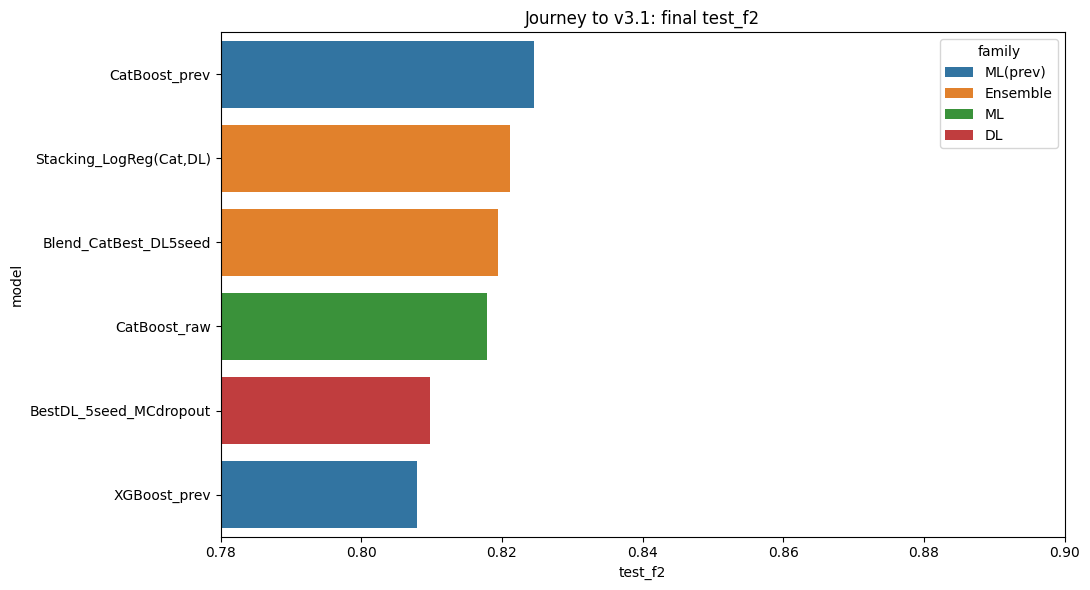

In [11]:
ml_prev = pd.DataFrame([
    {'model': 'CatBoost_prev', 'val_f2': 0.8231, 'test_f2': 0.8245, 'val_recall': 0.9420, 'test_recall': 0.9493, 'family': 'ML(prev)', 'threshold': np.nan},
    {'model': 'XGBoost_prev', 'val_f2': 0.8207, 'test_f2': 0.8079, 'val_recall': 0.8997, 'test_recall': 0.8901, 'family': 'ML(prev)', 'threshold': np.nan},
])

rows = [
    {'model': str(best_cat['model']), 'val_f2': float(best_cat['val_f2']), 'test_f2': float(best_cat['test_f2']), 'val_recall': float(best_cat['val_recall']), 'test_recall': float(best_cat['test_recall']), 'family': 'ML', 'threshold': float(best_cat['threshold'])},
    {'model': 'BestDL_5seed_MCdropout', 'val_f2': dl5_val_m['f2'], 'test_f2': dl5_test_m['f2'], 'val_recall': dl5_val_m['recall'], 'test_recall': dl5_test_m['recall'], 'family': 'DL', 'threshold': dl_thr5},
    {'model': 'Blend_CatBest_DL5seed', 'val_f2': float(best_blend['val_f2']), 'test_f2': float(best_blend['test_f2']), 'val_recall': float(best_blend['val_recall']), 'test_recall': float(best_blend['test_recall']), 'family': 'Ensemble', 'threshold': float(best_blend['threshold'])},
    {'model': 'Stacking_LogReg(Cat,DL)', 'val_f2': meta_train_m['f2'], 'test_f2': meta_test_m['f2'], 'val_recall': meta_train_m['recall'], 'test_recall': meta_test_m['recall'], 'family': 'Ensemble', 'threshold': meta_thr},
]

leaderboard = pd.concat([ml_prev, pd.DataFrame(rows)], ignore_index=True)
print('Full leaderboard (by test_f2):')
display(leaderboard.sort_values('test_f2', ascending=False).round(4))

print(f'\nConstrained leaderboard: recall >= {RECALL_MIN} (test)')
cons = leaderboard[leaderboard['test_recall'] >= RECALL_MIN].sort_values('test_f2', ascending=False)
display(cons.round(4))

plt.figure(figsize=(11, 6))
sns.barplot(data=leaderboard.sort_values('test_f2', ascending=False), x='test_f2', y='model', hue='family')
plt.title('Journey to v3.1: final test_f2')
plt.xlim(0.78, max(0.9, float(leaderboard['test_f2'].max()) + 0.02))
plt.tight_layout()
plt.show()